# Chilli Yield PredictionTrains a regressor to estimate chilli yield (kg/acre) from seven sensorchannels logged by the field node.**Important:** the yield target is *simulated*, not measured — it is generatedfrom the input features by the hand-specified formula in the cell below.See [docs/models.md](../../docs/models.md#yield-target) for the full disclosure.Data: `../data/chilli_data.xlsx`

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

ds = pd.read_excel('../data/chilli_data.xlsx')
ds

,Soil Temperature,N,P,K,Moisture,Humidity,Ambient Temperature
0,33.7,203,38,53,107,22.8,38.7
1,32.5,208,38,53,107,24.0,37.5
2,31.7,212,38,53,107,30.9,36.7
3,31.2,218,38,53,107,42.8,36.2
4,31.0,129,38,54,108,20.0,36.0
...,...,...,...,...,...,...,...
729,20.6,195,20,28,56,36.1,25.6
730,20.6,193,20,28,55,36.5,25.6
731,20.7,193,20,28,56,36.7,25.7
732,20.8,194,20,28,56,36.7,25.8


In [4]:
names = {"Soil Temperature": "Soil_Temp", "Ambient Temperature": "Air_Temp"}
ds.rename(columns = names, inplace = True)
ds

,Soil_Temp,N,P,K,Moisture,Humidity,Air_Temp
0,33.7,203,38,53,107,22.8,38.7
1,32.5,208,38,53,107,24.0,37.5
2,31.7,212,38,53,107,30.9,36.7
3,31.2,218,38,53,107,42.8,36.2
4,31.0,129,38,54,108,20.0,36.0
...,...,...,...,...,...,...,...
729,20.6,195,20,28,56,36.1,25.6
730,20.6,193,20,28,55,36.5,25.6
731,20.7,193,20,28,56,36.7,25.7
732,20.8,194,20,28,56,36.7,25.8


In [5]:
np.random.seed(42)

ds["Yield (Kg/Acre)"] = (
    3200  # Base value
    + 2 * ds["Soil_Temp"]
    - 1.5 * ds["N"]
    + 3 * ds["P"]
    + 3 * ds["K"]
    + 1.2 * ds["Moisture"]
    - 2 * ds["Humidity"]
    + 2 * ds["Air_Temp"]
    + np.random.normal(0, 15, len(ds))  # Adding small noise
)

ds["Yield (Kg/Acre)"] = ds["Yield (Kg/Acre)"].clip(3000, 3500)
ds

,Soil_Temp,N,P,K,Moisture,Humidity,Air_Temp,Yield (Kg/Acre)
0,33.7,203,38,53,107,22.8,38.7,3403.550712
1,32.5,208,38,53,107,24.0,37.5,3379.326035
2,31.7,212,38,53,107,30.9,36.7,3368.115328
3,31.2,218,38,53,107,42.8,36.2,3346.445448
4,31.0,129,38,54,108,20.0,36.0,3500.000000
...,...,...,...,...,...,...,...,...
729,20.6,195,20,28,56,36.1,25.6,3127.225429
730,20.6,193,20,28,55,36.5,25.6,3142.837679
731,20.7,193,20,28,56,36.7,25.7,3126.424408
732,20.8,194,20,28,56,36.7,25.8,3146.123791


In [6]:
ds.dropna(inplace = True)
ds

,Soil_Temp,N,P,K,Moisture,Humidity,Air_Temp,Yield (Kg/Acre)
0,33.7,203,38,53,107,22.8,38.7,3403.550712
1,32.5,208,38,53,107,24.0,37.5,3379.326035
2,31.7,212,38,53,107,30.9,36.7,3368.115328
3,31.2,218,38,53,107,42.8,36.2,3346.445448
4,31.0,129,38,54,108,20.0,36.0,3500.000000
...,...,...,...,...,...,...,...,...
729,20.6,195,20,28,56,36.1,25.6,3127.225429
730,20.6,193,20,28,55,36.5,25.6,3142.837679
731,20.7,193,20,28,56,36.7,25.7,3126.424408
732,20.8,194,20,28,56,36.7,25.8,3146.123791


<Axes: >

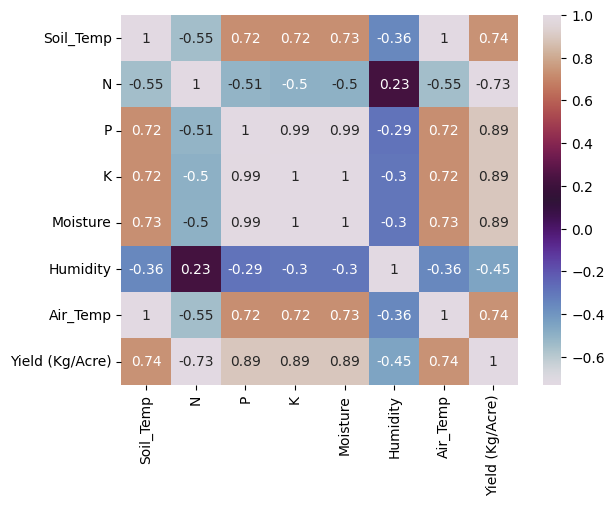

In [7]:
corr = ds.corr()
sns.heatmap(corr, cmap = 'twilight', annot = True)


In [8]:
from sklearn.model_selection import train_test_split

X = ds.drop(['Yield (Kg/Acre)'], axis = 1)
y = ds['Yield (Kg/Acre)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 1054.0069260882208
R-squared: 0.925028902264865


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  384.69536737453984
R2:  0.9726367699567884


In [11]:
from sklearn.neural_network import MLPRegressor

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(100, 50, 25), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 3092.4792405455573
R-squared (R2): 0.7800331689970211


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  353.96997761408863
R2:  0.9748222548351754


In [13]:
from sklearn.svm import SVR

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

y_pred = svr_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  4754.3334406932645
R2:  0.6618261339415514


In [14]:
from sklearn.neighbors import KNeighborsRegressor

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)


knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 346.95944374966047
R-squared (R2): 0.9753209113492043


In [15]:
import joblib

joblib.dump((knn, sc), "yield_model.joblib")

['yield_model.joblib']

In [16]:
input_data = {
    'Soil_Temp': [25],
    'N': [180],  # Example value for N
    'P': [38],  # Example value for P
    'K': [50],  # Example value for K,  # Example value for Soil Temperature
    'Moisture': [85],  # Example value for Moisture
    'Humidity': [60],  # Example value for Humidity
    'Air_Temp': [30],  # Example value for Ambient Temperature
}

input_df = pd.DataFrame(input_data) # Assuming 'sc' is your StandardScaler object
input_df_scaled = sc.transform(input_df)

# Make the prediction
prediction = knn.predict(input_df_scaled)

# Print the prediction
print("Predicted Yield (Kg/Acre):", prediction[0])

Predicted Yield (Kg/Acre): 3205.353430378358
